<a href="https://colab.research.google.com/github/nazary1212/4010_Project/blob/main/SHM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!unzip -q sensordata.zip -d /content/

#**Data Preprocessing & Statistics**


##Downsampling

🔍 Loading files and binning frequencies...
✅ Downsampling Complete. Total Individual Signatures: 40


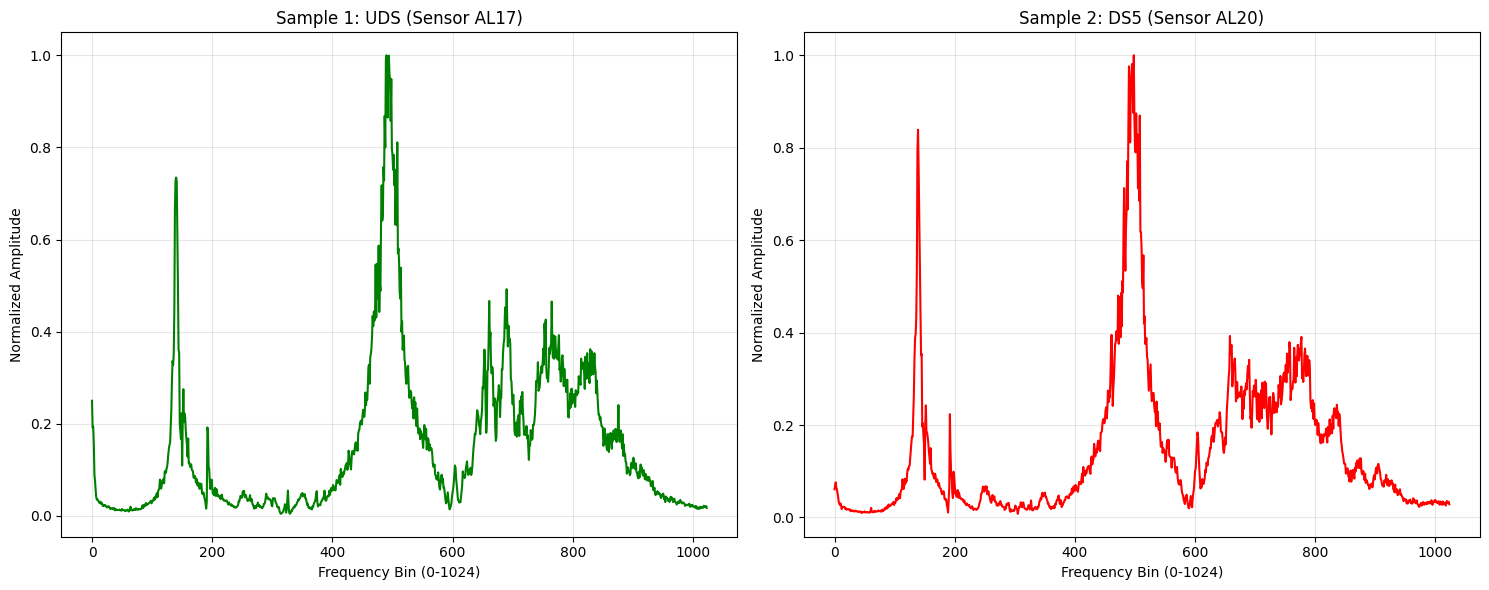

In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
BASE_PATH = '/content/sensordata'
SENSORS = ['AL17', 'AL18', 'AL19', 'AL20']
CASES = ['UDS', 'DS1', 'DS2', 'DS3', 'DS4', 'DS5', 'DS6', 'DS7', 'DS8']
TARGET_BINS = 1024

def downsample_fft(freqs, amps, target_bins=1024):
    new_freqs = np.linspace(freqs.min(), freqs.max(), target_bins)
    bin_width = (freqs.max() - freqs.min()) / target_bins
    new_amps = []
    for f in new_freqs:
        mask = (freqs >= f - bin_width/2) & (freqs <= f + bin_width/2)
        new_amps.append(np.mean(amps[mask]) if np.any(mask) else 0)
    return new_freqs, np.array(new_amps)

# --- 2. PROCESSING LOOP ---
runs = {}
print("🔍 Loading files and binning frequencies...")

for sensor in SENSORS:
    for case in CASES:
        path = os.path.join(BASE_PATH, sensor, f"{case}_fft")
        if os.path.exists(path):
            files = sorted([f for f in os.listdir(path) if f.endswith('.csv')])
            for f_name in files:
                run_id = f_name.replace(sensor, "SENSOR")
                if run_id not in runs:
                    runs[run_id] = {'label': case}

                try:
                    df = pd.read_csv(os.path.join(path, f_name))
                    if not df.empty:
                        _, binned = downsample_fft(df.iloc[:,0].values, df.iloc[:,1].values, TARGET_BINS)
                        # Normalize 0 to 1
                        runs[run_id][sensor] = binned / (np.max(binned) + 1e-10)
                except Exception as e:
                    print(f"Skipping {f_name}: {e}")

# --- 3. ALIGNMENT ---
X_list, y_list = [], []
info_list = [] # Keeping track of which sensor/case is which
label_map = {c: i for i, c in enumerate(CASES)}

for run_id, data in runs.items():
    for sensor in SENSORS:
        if sensor in data:
            X_list.append(data[sensor].reshape(TARGET_BINS, 1))
            y_list.append(label_map[data['label']])
            info_list.append({'case': data['label'], 'sensor': sensor})

X = np.array(X_list)
y = np.array(y_list)

print(f"✅ Downsampling Complete. Total Individual Signatures: {len(X)}")

# --- 4. VISUALIZATION (HARDCODED SAMPLES) ---
# We will pick two distinct examples to compare
plt.figure(figsize=(15, 6))

# Example A: Healthy Case (UDS) from Sensor AL17
idx_a = next(i for i, info in enumerate(info_list) if info['case'] == 'UDS' and info['sensor'] == 'AL17')
plt.subplot(1, 2, 1)
plt.plot(X[idx_a].flatten(), color='green', linewidth=1.5)
plt.title(f"Sample 1: {info_list[idx_a]['case']} (Sensor {info_list[idx_a]['sensor']})")
plt.xlabel("Frequency Bin (0-1024)")
plt.ylabel("Normalized Amplitude")
plt.grid(True, alpha=0.3)

# Example B: Damage Case (DS5) from Sensor AL20
idx_b = next(i for i, info in enumerate(info_list) if info['case'] == 'DS5' and info['sensor'] == 'AL20')
plt.subplot(1, 2, 2)
plt.plot(X[idx_b].flatten(), color='red', linewidth=1.5)
plt.title(f"Sample 2: {info_list[idx_b]['case']} (Sensor {info_list[idx_b]['sensor']})")
plt.xlabel("Frequency Bin (0-1024)")
plt.ylabel("Normalized Amplitude")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Damage State Comparisons

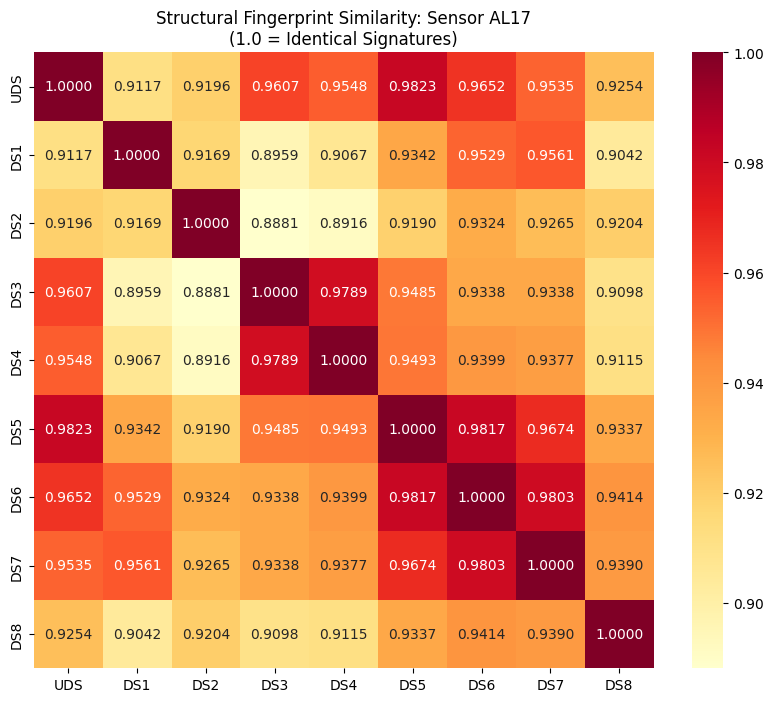

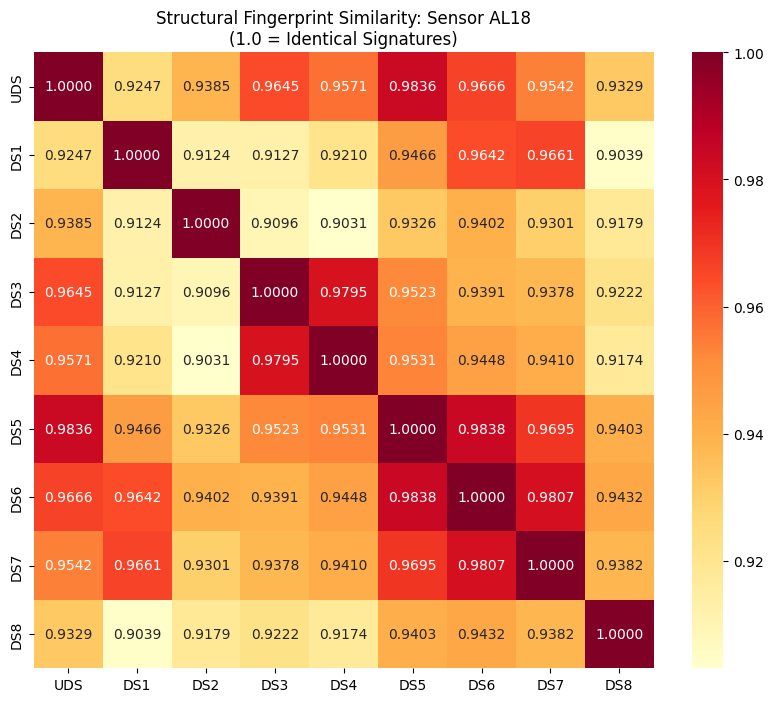

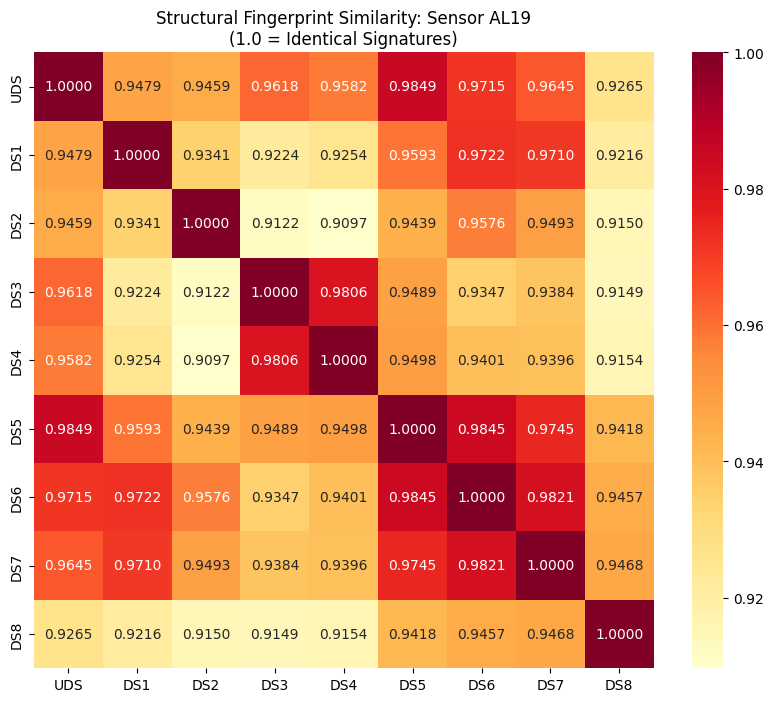

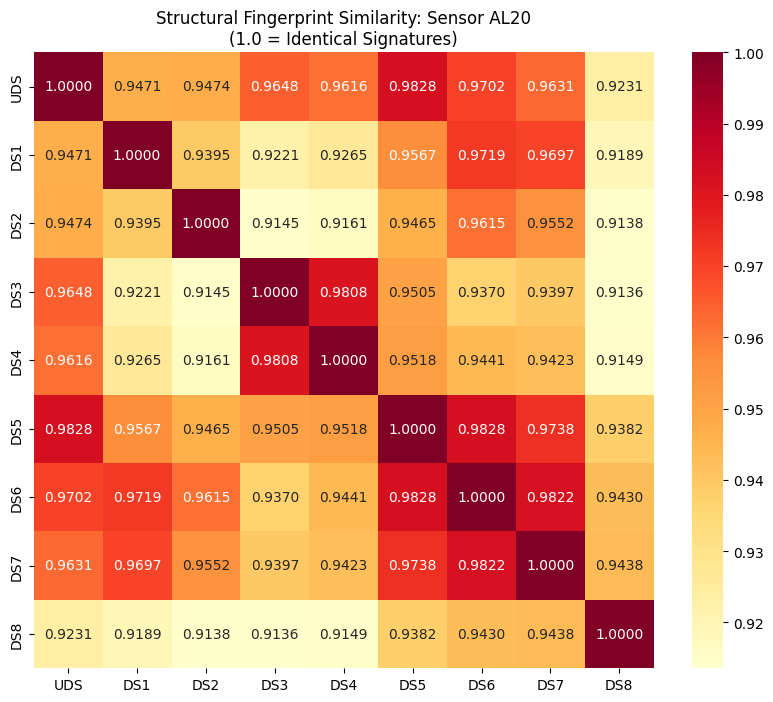


--- Structural Sensitivity Report ---
Sensor AL17:
   -> Average Similarity (UDS vs Damage): 94.6660%
   -> Most Distinct Damage: DS1 (Corr: 0.9117)
----------------------------------------
Sensor AL18:
   -> Average Similarity (UDS vs Damage): 95.2754%
   -> Most Distinct Damage: DS1 (Corr: 0.9247)
----------------------------------------
Sensor AL19:
   -> Average Similarity (UDS vs Damage): 95.7658%
   -> Most Distinct Damage: DS8 (Corr: 0.9265)
----------------------------------------
Sensor AL20:
   -> Average Similarity (UDS vs Damage): 95.7508%
   -> Most Distinct Damage: DS8 (Corr: 0.9231)
----------------------------------------


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# We will store the results for each sensor
sensor_stats = {}

# 1. Loop through each sensor to see how distinct the damage is at that location
for s_name in SENSORS:
    state_signatures = []
    active_cases = []

    for c_idx, c_name in enumerate(CASES):
        # We need to find the samples that belong to THIS case AND THIS sensor
        # In our info_list, we tracked exactly which is which
        indices = [i for i, info in enumerate(info_list)
                   if info['case'] == c_name and info['sensor'] == s_name]

        if indices:
            # Average the signatures (this handles your 2 UDS datasets automatically)
            # We flatten() because corrcoef needs a 1D vector per case
            mean_sig = np.mean(X[indices], axis=0).flatten()
            state_signatures.append(mean_sig)
            active_cases.append(c_name)

    # 2. Calculate Correlation Matrix (Similarity)
    # This compares every case against every other case for this specific sensor
    corr_matrix = np.corrcoef(state_signatures)
    sensor_stats[s_name] = {
        'matrix': corr_matrix,
        'cases': active_cases
    }

    # 3. Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap='YlOrRd',
                xticklabels=active_cases, yticklabels=active_cases)
    plt.title(f"Structural Fingerprint Similarity: Sensor {s_name}\n(1.0 = Identical Signatures)")
    plt.show()

# 4. Print the "Sensitivity" Report
print("\n--- Structural Sensitivity Report ---")
for s_name in SENSORS:
    # Correlation between the first row (UDS) and all other Damage States
    matrix = sensor_stats[s_name]['matrix']
    # index 0 is UDS, index 1: are the damage states
    uds_vs_damage = matrix[0, 1:]
    avg_sim = np.mean(uds_vs_damage)

    print(f"Sensor {s_name}:")
    print(f"   -> Average Similarity (UDS vs Damage): {avg_sim:.4%}")
    print(f"   -> Most Distinct Damage: {active_cases[np.argmin(uds_vs_damage)+1]} (Corr: {np.min(uds_vs_damage):.4f})")
    print("-" * 40)

##Multi-Channel 1D-CNN (Convolutional Neural Network).

The Concept
This model is a Single-Sensor 1D Convolutional Neural Network. It has been trained to recognize the spectral fingerprints of damage—specific shifts in frequency and amplitude that occur when structural integrity changes.

How it Works
Pattern Extraction (Convolution): The model uses filters to "scan" the 1024-bin frequency signature. It searches for specific local features, such as the sharpening or blunting of resonance peaks.

Universal Features: By using Global Average Pooling, the model focuses on the existence of damage patterns rather than their exact location. This allows the AI to diagnose sensors it has never seen before (e.g., AL21–24), as long as the "physics" of the damage remains consistent across the deck.

Classification: The final layers weigh these extracted features to determine the probability of each damage state (UDS to DS8).

Strengths & Limitations
Strength: Spatial Independence. It is a "Universal Reader." You can move sensors or add new ones without retraining the entire system.

Limitation: Spectral Overlap. Because it looks at sensors individually, it may struggle if two different damage states (like DS3 and DS8) produce identical frequency shifts at a specific sensor location, as it lacks the "cross-reference" of neighboring sensors to break the tie.

In [39]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

def augment_data_single(X, y, target_samples_per_class=100):
    """
    X: Current shape (40, 1024, 1)
    y: Current shape (40,)
    """
    X_aug, y_aug = [], []

    for class_idx in np.unique(y):
        # Get all original single-sensor samples for this class
        class_samples = X[y == class_idx]

        # We have 9 classes. Let's aim for 100 samples per class to give the AI enough to learn.
        needed = target_samples_per_class - len(class_samples)

        # Keep the originals
        for s in class_samples:
            X_aug.append(s)
            y_aug.append(class_idx)

        # Create "Fake but Realistic" variations
        for _ in range(max(0, needed)):
            # Pick a random original sensor reading to mutate
            random_sample = class_samples[np.random.randint(len(class_samples))]

            # Add tiny white noise
            noise = np.random.normal(0, 0.002, random_sample.shape)

            X_aug.append(random_sample + noise)
            y_aug.append(class_idx)

    return np.array(X_aug), np.array(y_aug)

# 1. Boost your dataset
# This turns your 40 real readings into 900 training signals (100 per damage case)
X_boosted, y_boosted = augment_data_single(X, y, target_samples_per_class=100)

# 2. Reshape & Categorize
# Our X is already (900, 1024, 1), so no transpose needed!
y_categorical = to_categorical(y_boosted, num_classes=len(CASES))

# 3. Final Split
X_train, X_test, y_train, y_test = train_test_split(
    X_boosted, y_categorical, test_size=0.2, stratify=y_boosted, random_state=42
)

print(f"✅ Data Preparation Complete!")
print(f"X_train Shape: {X_train.shape} -> (Samples, Bins, Sensors)")
print(f"Total Training Samples: {X_train.shape[0]}")
print(f"Total Testing Samples:  {X_test.shape[0]}")

✅ Data Preparation Complete!
X_train Shape: (720, 1024, 1) -> (Samples, Bins, Sensors)
Total Training Samples: 720
Total Testing Samples:  180


In [42]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_simple_bridge_cnn(input_shape, num_classes):
    model = models.Sequential(name="Robust_Bridge_CNN_SingleSensor")

    # Layer 1: Extract broad frequency features
    # Input shape is now (1024, 1)
    model.add(layers.Conv1D(filters=16, kernel_size=11, activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=4))

    # Layer 2: Refine patterns
    model.add(layers.Conv1D(filters=32, kernel_size=5, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling1D())

    # Layer 3: Decision Head with Dropout to prevent memorizing the augmented noise
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# --- INITIALIZATION ---
# Change: input_shape is now (1024, 1) because we look at one sensor at a time
model = build_simple_bridge_cnn(input_shape=(1024, 1), num_classes=len(CASES))

# Define Early Stopping to save time and prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# --- IMPROVED TRAINING WITH STABILIZATION ---

# This callback slows down the learning if progress stalls
reduce_lr = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 0.0005 * 0.9**epoch)

# Re-build fresh to clear the "bouncing" memory
model = build_simple_bridge_cnn(input_shape=(1024, 1), num_classes=len(CASES))

print("🚀 Starting Stabilized Training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

🚀 Starting Stabilized Training...
Epoch 1/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.1468 - loss: 2.1858 - val_accuracy: 0.1111 - val_loss: 2.1970 - learning_rate: 5.0000e-04
Epoch 2/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3304 - loss: 2.1264 - val_accuracy: 0.1111 - val_loss: 2.2004 - learning_rate: 4.5000e-04
Epoch 3/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4783 - loss: 2.0521 - val_accuracy: 0.1111 - val_loss: 2.2115 - learning_rate: 4.0500e-04
Epoch 4/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5777 - loss: 1.9473 - val_accuracy: 0.1111 - val_loss: 2.2346 - learning_rate: 3.6450e-04
Epoch 5/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5565 - loss: 1.8621 - val_accuracy: 0.1111 - val_loss: 2.2721 - learning_rate: 3.2805e-04
Epoch 6/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5672 - loss: 1.7621 - val_accuracy: 0.1111 - val_loss: 2.3319 - learning_rate: 2.9525e-04
Epoch 7/40
45/45 ━━━━━━━━━━━━━━━━━━━

Testing on Unseen Data (21-24)

In [44]:
!unzip -q sensordata2.zip -d /content/

replace /content/__MACOSX/._sensordata2? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [47]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
# Point this to your newly unzipped folder
BASE_PATH = '/content/sensordata2'
SENSORS = ['AL21', 'AL22', 'AL23', 'AL24']
CASES = ['UDS', 'DS1', 'DS2', 'DS3', 'DS4', 'DS5', 'DS6', 'DS7', 'DS8']
TARGET_BINS = 1024

def downsample_fft(freqs, amps, target_bins=1024):
    new_freqs = np.linspace(freqs.min(), freqs.max(), target_bins)
    bin_width = (freqs.max() - freqs.min()) / target_bins
    new_amps = []
    for f in new_freqs:
        mask = (freqs >= f - bin_width/2) & (freqs <= f + bin_width/2)
        new_amps.append(np.mean(amps[mask]) if np.any(mask) else 0)
    return new_freqs, np.array(new_amps)

# --- 2. PROCESSING LOOP ---
unseen_runs = {}
print(f"🔍 Loading files from {BASE_PATH} and binning...")

for sensor in SENSORS:
    for case in CASES:
        path = os.path.join(BASE_PATH, sensor, f"{case}_fft")
        if os.path.exists(path):
            files = sorted([f for f in os.listdir(path) if f.endswith('.csv')])
            for f_name in files:
                run_id = f_name.replace(sensor, "SENSOR")
                if run_id not in unseen_runs:
                    unseen_runs[run_id] = {'label': case}

                try:
                    df = pd.read_csv(os.path.join(path, f_name))
                    if not df.empty:
                        _, binned = downsample_fft(df.iloc[:,0].values, df.iloc[:,1].values, TARGET_BINS)
                        # Normalize 0 to 1
                        unseen_runs[run_id][sensor] = binned / (np.max(binned) + 1e-10)
                except Exception as e:
                    print(f"Skipping {f_name}: {e}")

# --- 3. CREATE X_unseen AND y_unseen ---
X_unseen_list, y_unseen_list = [], []
info_unseen = []
label_map = {c: i for i, c in enumerate(CASES)}

for run_id, data in unseen_runs.items():
    for sensor in SENSORS:
        if sensor in data:
            # Reshape to (1024, 1) to match what the CNN expects
            X_unseen_list.append(data[sensor].reshape(TARGET_BINS, 1))
            y_unseen_list.append(label_map[data['label']])
            info_unseen.append({'case': data['label'], 'sensor': sensor, 'file': run_id})

X_unseen = np.array(X_unseen_list)
y_unseen = np.array(y_unseen_list)

if X_unseen.size > 0:
    print(f"✅ Unseen Dataset Created!")
    print(f"Total New Samples: {X_unseen.shape[0]}")
    print(f"Shape: {X_unseen.shape[1:]}")
else:
    print("❌ No data loaded. Check if 'sensordata2' folder structure matches.")

🔍 Loading files from /content/sensordata2 and binning...
✅ Unseen Dataset Created!
Total New Samples: 40
Shape: (1024, 1)


In [57]:
import pandas as pd
import numpy as np

# 1. Filter our unseen data specifically for AL21
target_sensor = 'AL21'
indices = [i for i, info in enumerate(info_unseen) if info['sensor'] == target_sensor]

if len(indices) == 0:
    print(f"❌ No data found for sensor {target_sensor}. Check your loading step.")
else:
    # Prepare samples and ground truth
    samples_to_test = X_unseen[indices]
    true_labels = [info_unseen[i]['case'] for i in indices]

    # 2. Model Prediction
    # samples_to_test is already (N, 1024, 1)
    predictions = model.predict(samples_to_test, verbose=0)
    predicted_indices = np.argmax(predictions, axis=1)

    # 3. Compile Results
    results = []
    for i, pred_idx in enumerate(predicted_indices):
        pred_case = CASES[pred_idx]
        confidence = predictions[i][pred_idx]

        results.append({
            'Actual Damage': true_labels[i],
            'Predicted Damage': pred_case,
            'Confidence': f"{confidence:.2%}",
            'Result': '✅ Correct' if true_labels[i] == pred_case else '❌ Wrong'
        })

    # Display as a clean Table
    results_df = pd.DataFrame(results)
    print(f"\n--- 🔎 BLIND TEST RESULTS: SENSOR {target_sensor} ---")
    print(results_df.to_string(index=False))

    # 4. Final Accuracy for this specific sensor
    accuracy = (results_df['Result'] == '✅ Correct').mean() * 100
    print(f"\n🎯 Overall Accuracy for {target_sensor}: {accuracy:.2f}%")


--- 🔎 BLIND TEST RESULTS: SENSOR AL21 ---
Actual Damage Predicted Damage Confidence    Result
          UDS              DS5     29.61%   ❌ Wrong
          UDS              UDS     24.03% ✅ Correct
          DS1              DS1     27.63% ✅ Correct
          DS2              DS2     41.27% ✅ Correct
          DS3              DS3     62.59% ✅ Correct
          DS4              DS4     80.04% ✅ Correct
          DS5              DS5     35.93% ✅ Correct
          DS6              DS6     24.85% ✅ Correct
          DS7              DS7     56.52% ✅ Correct
          DS8              DS3     25.13%   ❌ Wrong

🎯 Overall Accuracy for AL21: 80.00%


📊 Generating confidence breakdown for AL21...


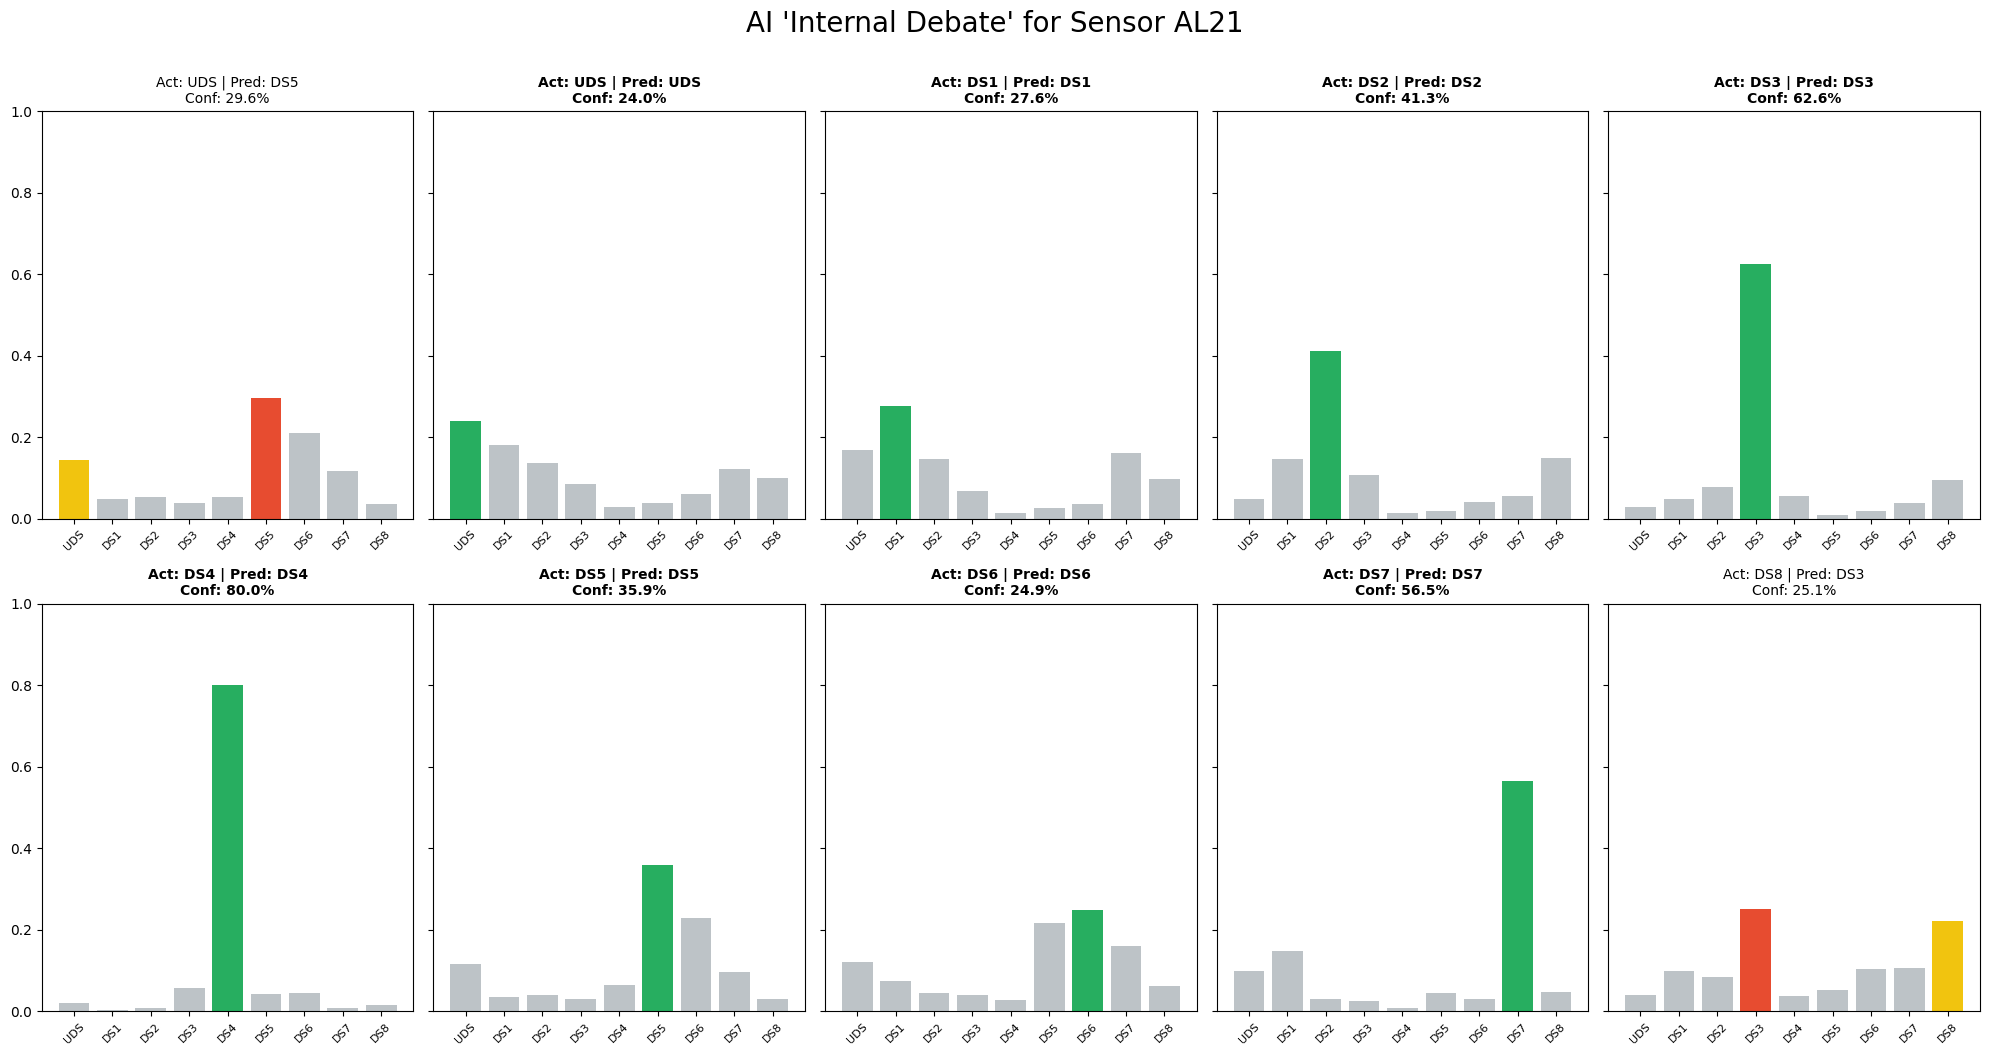

In [58]:
# 1. Prepare the plot grid (2 rows, 5 columns for the 10 samples)
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

print(f"📊 Generating confidence breakdown for {target_sensor}...")

for i, idx in enumerate(al21_indices):
    sample = X_unseen[idx].reshape(1, 1024, 1)
    actual_case = info_unseen[idx]['case']

    # Get probabilities
    preds = model.predict(sample, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_case = CASES[pred_idx]

    # Styling
    ax = axes[i]
    colors = ['#BDC3C7'] * len(CASES) # Neutral Gray

    if actual_case == pred_case:
        colors[pred_idx] = '#27AE60' # Success Green
    else:
        colors[pred_idx] = '#E74C30' # Error Red
        actual_case_idx = CASES.index(actual_case)
        colors[actual_case_idx] = '#F1C40F' # Yellow highlight for where it SHOULD have been

    # Plotting bar chart
    ax.bar(CASES, preds, color=colors)
    ax.set_title(f"Act: {actual_case} | Pred: {pred_case}\nConf: {preds[pred_idx]:.1%}",
                 fontsize=10, fontweight='bold' if actual_case == pred_case else 'normal')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    if i % 5 != 0: ax.set_yticklabels([]) # Clean up the inner labels

plt.tight_layout()
plt.suptitle(f"AI 'Internal Debate' for Sensor {target_sensor}", fontsize=20, y=1.05)
plt.show()